<a href="https://colab.research.google.com/github/loyedan/ELAIS-QST-Mini-Project_Assignments/blob/main/Task_1_Interest_rates_daniel_ofori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Forecasting_the_Health_of_Ghana's_Economy_Using_Macroeconomic_Indicators**

In [5]:
pip install tensorflow==2.10 pennylane==0.26 autoray==0.6.0 openai==0.28

/content/drive/MyDrive/ELAIS-QST-Mini-Project_Assignments/qst_quantum_enhanced_lstm_merchandize_trade_flows.py

In [6]:
import numpy as np
import pandas as pd
import pennylane as qml
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input, Lambda
from keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger
from pennylane import numpy as pnp
from pennylane.qnn import KerasLayer
from keras.models import Model
from keras.layers import Reshape

In [7]:
# Set TensorFlow global policy to float64
tf.keras.backend.set_floatx('float64')


In [8]:
# Define the file path
file_path = '/content/interest_rates_daniel_ofori.csv'

data = pd.read_csv(file_path)

data

col = ['Year', 'Variables', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

In [9]:
# Verify that the variables are present in the columns of the DataFrame
missing_vars = [var for var in col if var not in data.columns]
if missing_vars:
    print(f"The following variables are not present in the DataFrame columns: {missing_vars}")


In [10]:
# Filter the DataFrame to include only the selected variables that exist in the DataFrame
col = [var for var in col if var in data.columns]
filtered_data = data[col]

In [11]:
# Check if the filtered DataFrame is empty
if filtered_data.empty:
    raise ValueError("The filtered DataFrame is empty. Ensure the variables match the DataFrame columns.")

In [16]:
# Function to replace zeros with the mean of the non-zero elements in the row (for numeric columns only)
def replace_zeros_with_row_mean(row):
    # Select only numeric values
    numeric_row = pd.to_numeric(row, errors='coerce')

In [17]:
# Calculate mean of non-zero elements in the row
non_zero_mean = numeric_row[numeric_row != 0].mean()

NameError: name 'numeric_row' is not defined

In [18]:
# Function to replace zeros with the mean of the non-zero elements in the row (for numeric columns only)
def replace_zeros_with_row_mean(row):
    # Select only numeric values
    numeric_row = pd.to_numeric(row, errors='coerce')

    # Calculate mean of non-zero elements in the row
    non_zero_mean = numeric_row[numeric_row != 0].mean()

    # Replace zeros with the calculated mean
    row = row.mask(numeric_row == 0, non_zero_mean)

    return row

In [19]:
# Assuming filtered_data is a pandas DataFrame
# Apply the function to numeric columns only
filtered_data = filtered_data.apply(replace_zeros_with_row_mean, axis=1)

# Shuffle the data indices
indices = np.random.permutation(len(filtered_data))

# Calculate sizes for training and testing sets
train_size = int(len(indices) * 0.8)

# Split indices into training and testing sets
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Use iloc to select rows by integer-location based indexing
train_data = filtered_data.iloc[train_indices]
test_data = filtered_data.iloc[test_indices]

def create_dataset(dataset, time_step=1):
    X, Y = [], []

    for i in range(len(dataset) - time_step - 1):
        a = dataset.iloc[i:(i + time_step), :]  # Use iloc for DataFrame slicing
        X.append(a.values)  # Convert sliced DataFrame to NumPy array
        Y.append(dataset.iloc[i + time_step, :].values)  # Convert target to NumPy array

    return np.array(X), np.array(Y)


In [23]:
# Set time_step to 12
time_step = 12

# Create the training and testing datasets
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Step 1: Pivot the DataFrame so that 'Variables' becomes columns and each row corresponds to a year
data_pivot = data.pivot(index='Year', columns='Variables', values=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Step 2: Flatten the pivoted columns so that you get a multi-index DataFrame where months and variables are columns
data_pivot.columns = [f'{month}_{var}' for month, var in data_pivot.columns]

# Step 3: Convert the DataFrame to a NumPy array (this is your target data, y_train)
y_train = data_pivot.values.reshape(data_pivot.shape[0], 12, 12)  # Reshape to (n_samples, 12 months, 11 variables)

# Check the shape of y_train
print(y_train.shape)  # Should output (n_samples, 12, 12)

(5, 12, 12)


In [21]:
# Step 1: Pivot the DataFrame so that 'Variables' becomes columns and each row corresponds to a year
data_pivot = data.pivot(index='Year', columns='Variables', values=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Step 2: Flatten the pivoted columns so that you get a multi-index DataFrame where months and variables are columns
data_pivot.columns = [f'{month}_{var}' for month, var in data_pivot.columns]

# Calculate the correct shape based on the actual dimensions of the pivoted data
num_years = data_pivot.shape[0]  # Get the actual number of years
num_months = 12  # Assuming 12 months
num_variables = len(data_pivot.columns) // num_months  # Calculate the number of variables

# Step 3: Convert the DataFrame to a NumPy array (this is your target data, y_train)
# Reshape using the calculated shape
y_train = data_pivot.values.reshape(num_years, num_months, num_variables)

# Check the shape of y_train
print(y_train.shape)

(5, 12, 12)


In [24]:
# ---------------------------
# Data Preprocessing
# ---------------------------

# Function to replace NaNs and zeros with the mean of non-zero elements in the row
def replace_nan_with_row_mean(row):
    numeric_row = pd.Series(row)
    numeric_row = pd.to_numeric(numeric_row, errors='coerce')
    non_zero_mean = numeric_row[(numeric_row != 0) & numeric_row.notna()].mean()
    numeric_row = numeric_row.mask((numeric_row == 0) | numeric_row.isna(), non_zero_mean)
    return numeric_row.values

# Assuming data_pivot is a pandas DataFrame
data_pivot = data_pivot.apply(replace_nan_with_row_mean)

# Check data_pivot shape
print("Shape of data_pivot before processing:", data_pivot.shape)

# Calculate number of training samples
n_train_samples = int(data_pivot.shape[0] * 0.8)
total_elements = data_pivot.shape[0] * data_pivot.shape[1]

# Calculate elements needed for reshaping
expected_train_elements = n_train_samples * 12 * 11
expected_test_elements = (data_pivot.shape[0] - n_train_samples) * 12 * 11

# Check if there are enough elements for reshaping
print("Total elements available in data_pivot:", total_elements)
print("Total elements required for reshaping:", expected_train_elements + expected_test_elements)

# Flatten data and reshape for training and testing
data_pivot_flat = data_pivot.values.flatten()

X_train = data_pivot_flat[:expected_train_elements].reshape(n_train_samples, 12, 11)
y_train = X_train.copy()  # Assuming y_train is the same as X_train

X_test = data_pivot_flat[expected_train_elements:expected_train_elements + expected_test_elements].reshape(-1, 12, 11)
y_test = X_test.copy()  # Assuming y_test is the same as X_test

# Function to remove commas and convert strings to floats
def remove_commas(data):
    return np.vectorize(lambda x: float(str(x).replace(',', '')))(data)

X_train = remove_commas(X_train)
X_test = remove_commas(X_test)
y_train = remove_commas(y_train)
y_test = remove_commas(y_test)

# Reshape data for scaling
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])

# Scale the data
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler_X.fit_transform(X_train_reshaped)
X_test_scaled = scaler_X.transform(X_test_reshaped)

# Reshape back to 3D
X_train_scaled = X_train_scaled.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])
X_test_scaled = X_test_scaled.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

# Ensure y_train and y_test are not flattened
y_train_scaled = X_train_scaled.copy()  # y_train should match X_train
y_test_scaled = X_test_scaled.copy()  # y_test should match X_test

X_train_scaled = np.array(X_train_scaled, dtype=np.float32)
X_test_scaled = np.array(X_test_scaled, dtype=np.float32)
y_train_scaled = np.array(X_train_scaled, dtype=np.float32)
y_test_scaled = np.array(y_test_scaled, dtype=np.float32)


# Check shapes
print("X_train shape:", X_train_scaled.shape)
print("y_train shape:", y_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_test shape:", y_test_scaled.shape)

Shape of data_pivot before processing: (5, 144)
Total elements available in data_pivot: 720
Total elements required for reshaping: 660
X_train shape: (4, 12, 11)
y_train shape: (4, 12, 11)
X_test shape: (1, 12, 11)
y_test shape: (1, 12, 11)


In [25]:
# Define the quantum device
n_qubits = 11
dev = qml.device("default.qubit", wires=n_qubits)

# Define the quantum cell function
@qml.qnode(dev, interface='tf', diff_method='parameter-shift')
def quantum_lstm_cell(inputs, weights):
    inputs = tf.cast(inputs, dtype=tf.float64)
    weights = tf.cast(weights, dtype=tf.float64)

    # Pad inputs to match the number of qubits
    padded_inputs = tf.pad(inputs, [[0, 0], [0, n_qubits - tf.shape(inputs)[1]]])[:, :n_qubits]

    # Data encoding step
    for i in range(n_qubits):
        qml.RY(padded_inputs[0, i], wires=i)

    # Strongly entangling layers for LSTM-like processing
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    # Measure each qubit's Pauli- Z expectation value
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [26]:
# Custom Keras Layer that wraps the quantum LSTM cell
class QuantumLSTMTimeStepLayer(tf.keras.layers.Layer):
  def __init__(self, n_qubits, weight_shapes):
    super(QuantumLSTMTimeStepLayer, self).__init__()
    self.n_qubits = n_qubits
    self.q_weights = self.add_weight(
        shape=weight_shapes['weights'],
        initializer='random_normal',
        dtype='float64',
        trainable=True,
        name='q_weights'
    )

    def call(self, inputs):
      # Quantum computation within the keras Layer
      output = quantum_lstm_cell(inputs, self.q_weights)
      return tf.shape(tf.cast(output, dtype=tf.float64), (1, self.n_qubits))


In [27]:
# Build the Keras model with quantum LSTM
input_layer = tf.keras.layers.Input(shape=(12,11), name='input', dtype=tf.float64)
weight_shapes = {"weights": (2, n_qubits, 3)}

# Process each timestep with QuantumLSTMTimeStepLayer
timestep_outputs = []
for i in range(12):
  timestep = tf.keras.layers.Lambda(lambda x: x[:, i, :])(input_layer)
  timestep_layer = QuantumLSTMTimeStepLayer(n_qubits, weight_shapes)
  timestep_output = timestep_layer(timestep)
  timestep_outputs.append(timestep_output)

# Concatenate the timestep outputs along the time dimension
quantum_lstm_output = tf.keras.layers.Concatenate(axis=1, dtype=tf.float64)(timestep_outputs)

# Layer Normalization for compability in graph mode
layer_norm_out = tf.keras.layers.LayerNormalization(dtype=tf.float64)(quantum_lstm_output)

# Dropout layer
drop_out = tf.keras.layers.Dropout(0.5, name='dropout')(layer_norm_out)

# Dense layer
dense_out = tf.keras.layers.Dense(12 * 11, kernel_regularizer=l2(0.001), name='output', dtype=tf.float64)(drop_out)
output = tf.keras.layers.Reshape((12, 11))(dense_out)

# Define the model
model = tf.keras.models.Model(inputs=input_layer, outputs=output)


In [28]:
# Custom loss functipn
@tf.function
def custom_loss(y_true, y_pred):
  y_true = tf.cast(y_true, tf.float64)
  y_pred = tf.cast(y_true, tf.float64)
  x = y_true - y_pred
  loss = tf.reduce_mean(tf.square(x))
  return loss

# Custom root mean squared error function
def root_mean_squared_error(y_true, y_pred):
  return tf.sqrt(tf.reduce_mean(tf.square(y_pred-y_true)))

# Custom callback to log the gap between training and validation metrics
class GapMonitor(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        train_loss = logs['loss']
        val_loss = logs['val_loss']
        gap = val_loss - train_loss
        print(f" Loss Gap = {gap:.4f}")

        train_mse = logs['mean_squared_error']
        val_mse = logs['val_mean_squared_error']
        gap_mse = val_mse - train_mse
        print(f" MSE Gap = {gap_mse:.4f}")

        train_rmse = logs['root_mean_squared_error']
        val_rmse = logs['val_root_mean_squared_error']
        gap_rmse = val_rmse - train_rmse
        print(f" RMSE Gap = {gap_rmse:.4f}")

        train_mae = logs['mean_absolute_error']
        val_mae = logs['val_mean_absolute_error']
        gap_mae = val_mae - train_mae
        print(f" MAE Gap = {gap_mae:.4f}")


In [29]:
# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=custom_loss, metrics=['mean_squared_error', root_mean_squared_error, 'mean_absolute_error'])

# Ensure all input data is explicitly in float64
X_train_scaled = np.array(X_train_scaled, dtype=np.float64)
y_train_scaled = np.array(y_train_scaled, dtype=np.float64)
X_test_scaled = np.array(X_test_scaled, dtype=np.float64)
y_test_scaled = np.array(y_test_scaled, dtype=np.float64)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=200,
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, min_delta=0.001, restore_best_weights=True), GapMonitor()],
    verbose=1
)

print("Quantum-enhanced LSTM model trained successfully")

Epoch 1/200


1/1 [==============================] - ETA: 0s - loss: 0.1320 - mean_squared_error: 2.0687 - root_mean_squared_error: 1.4383 - mean_absolute_error: 1.1577 Loss Gap = -0.0026
 MSE Gap = -0.4652
 RMSE Gap = -0.1720
 MAE Gap = -0.1104
1/1 [==============================] - 2s 2s/step - loss: 0.1320 - mean_squared_error: 2.0687 - root_mean_squared_error: 1.4383 - mean_absolute_error: 1.1577 - val_loss: 0.1295 - val_mean_squared_error: 1.6035 - val_root_mean_squared_error: 1.2663 - val_mean_absolute_error: 1.0472
Epoch 2/200
1/1 [==============================] - ETA: 0s - loss: 0.1295 - mean_squared_error: 2.1807 - root_mean_squared_error: 1.4767 - mean_absolute_error: 1.2020 Loss Gap = -0.0025
 MSE Gap = -0.5927
 RMSE Gap = -0.2165
 MAE Gap = -0.1601
1/1 [==============================] - 0s 59ms/step - loss: 0.1295 - mean_squared_error: 2.1807 - root_mean_squared_error: 1.4767 - mean_absolute_error: 1.2020 - val_loss: 0.1269 - val_mean_squared_error: 1.5881 - val_root_mean_squared_error:

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 12, 11)]     0           []                               
                                                                                                  
 lambda (Lambda)                (None, 11)           0           ['input[0][0]']                  
                                                                                                  
 lambda_1 (Lambda)              (None, 11)           0           ['input[0][0]']                  
                                                                                                  
 lambda_2 (Lambda)              (None, 11)           0           ['input[0][0]']                  
                                                                                              

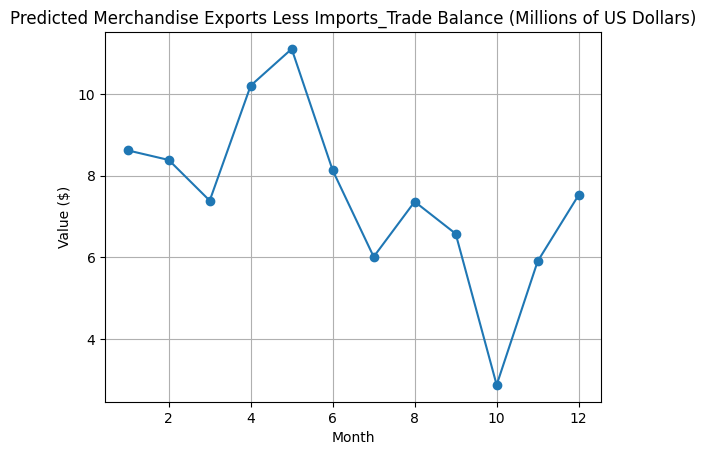

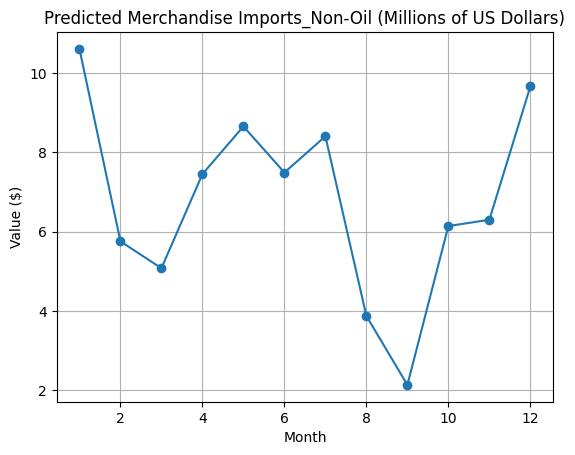

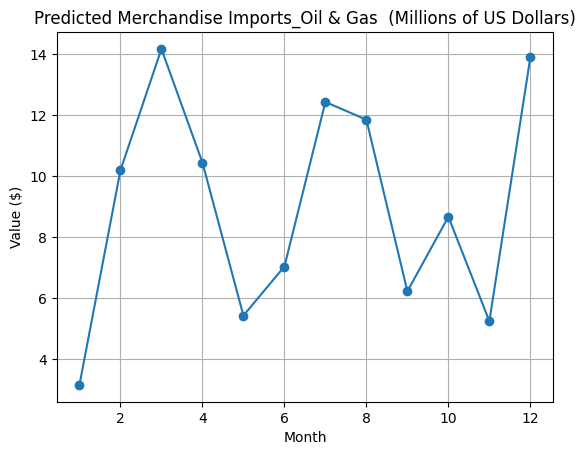

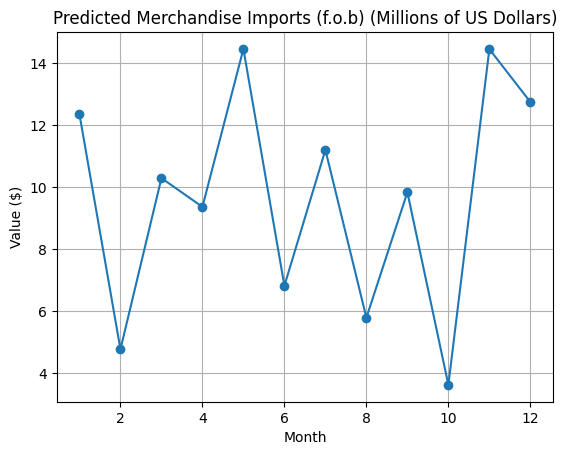

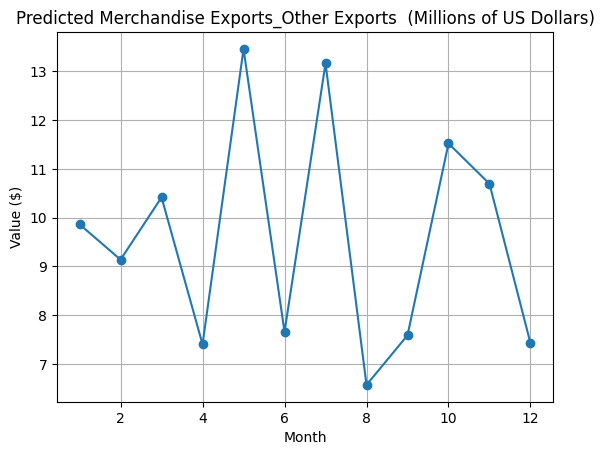

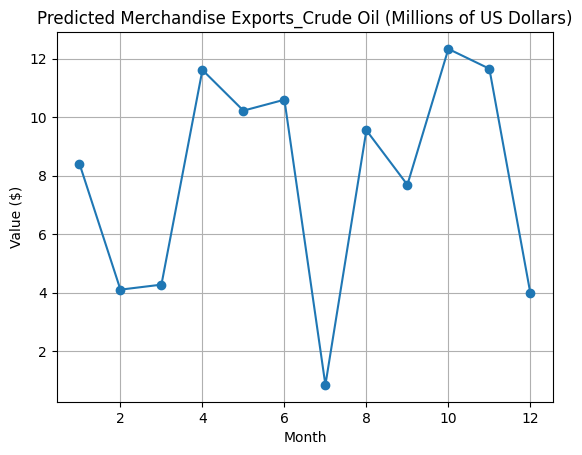

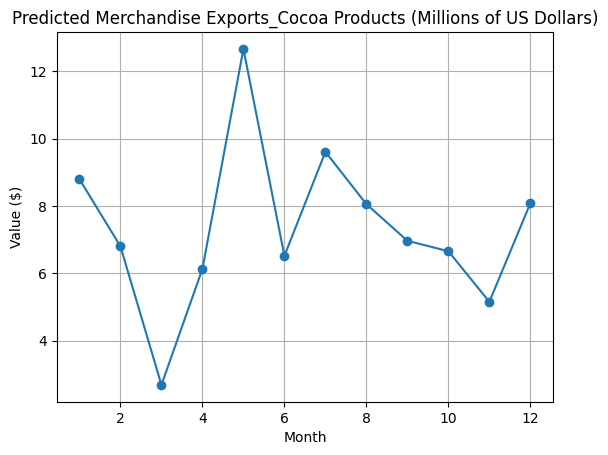

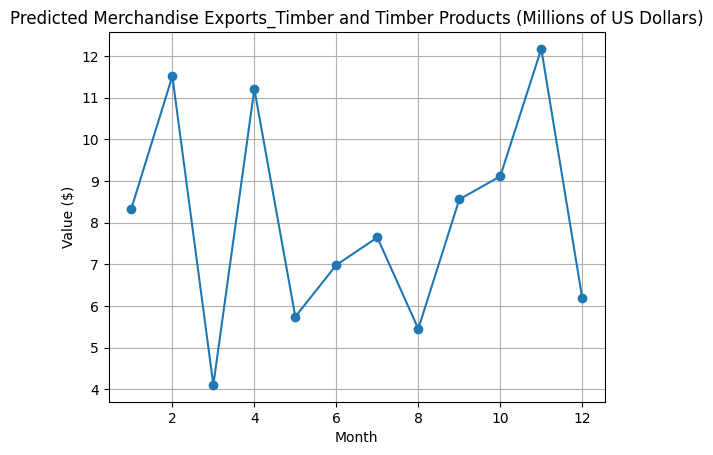

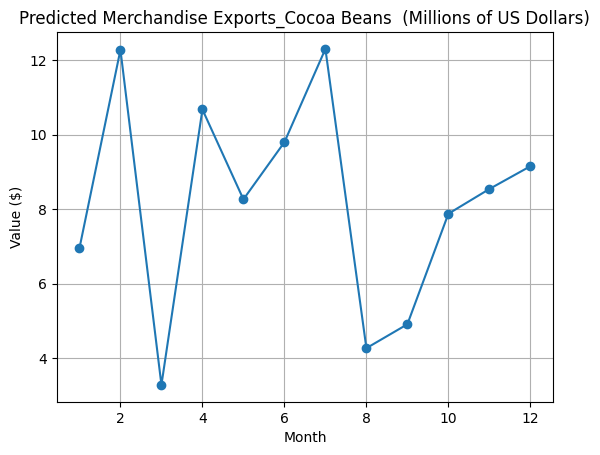

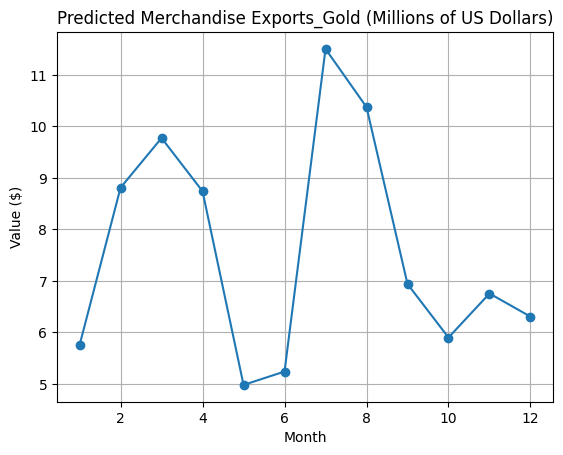

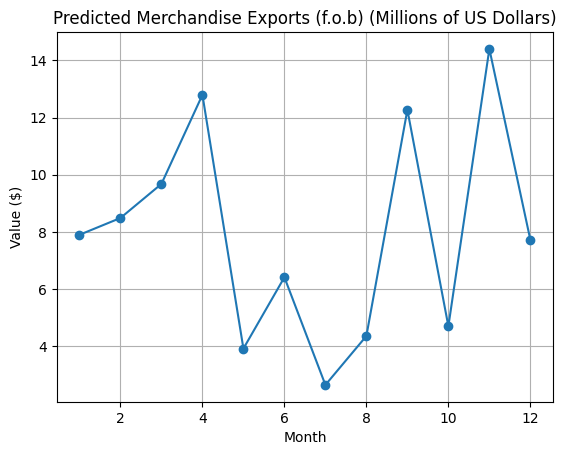

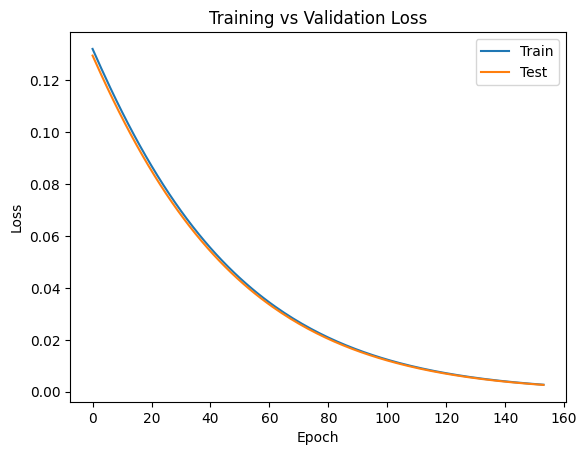

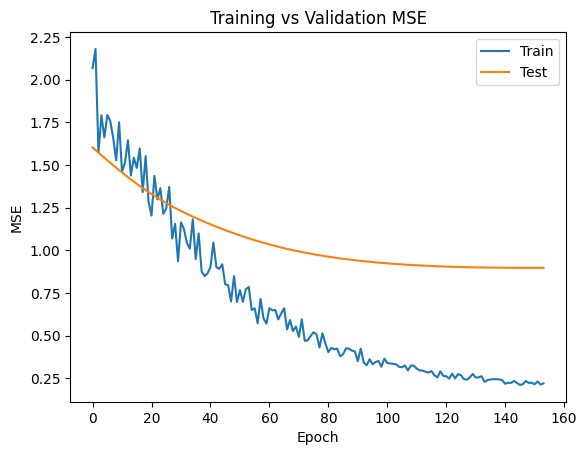

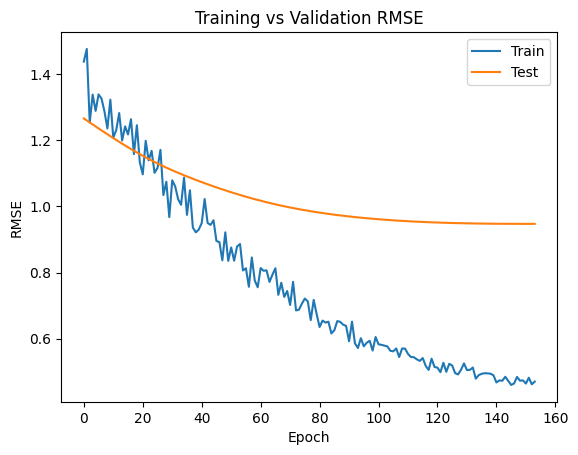

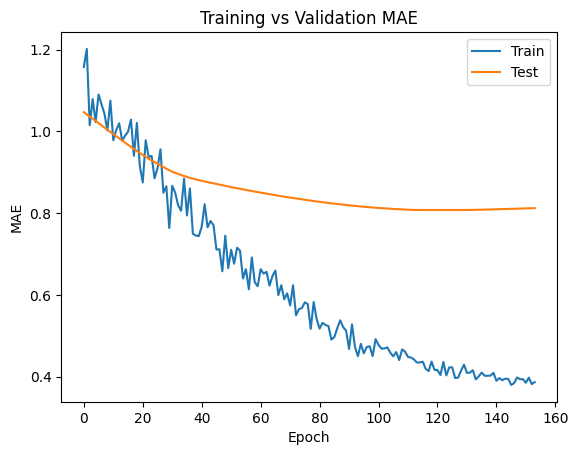

In [30]:
# Print the model summary
model.summary()

# Check the shape of your X_test
print("Shape of X_test:", X_test_scaled.shape)  # This should print something like (n_samples, timesteps, features)
# Check the shape of your y_test
print("Shape of y_test:", y_test_scaled.shape)  # This should print something like (n_samples, timesteps, features)

# Ensure X_test has at least 3 dimensions
if len(y_test_scaled.shape) == 3:
    # Select the last sample (assuming X_test[-1] has shape (timesteps, features))
    last_sample = X_test_scaled[-1].reshape((1, X_test_scaled.shape[1], X_test_scaled.shape[2]))  # Reshape to (1, timesteps, features)

    # Predict the next year value
    next_year_prediction = model.predict(last_sample)

    print('Next year prediction (scaled):', next_year_prediction)

    # Perform inverse transform to convert scaled predictions back to original
    reshaped_predictions = next_year_prediction.reshape(-1, next_year_prediction.shape[2])  # Flatten timesteps
    original_predictions = scaler_X.inverse_transform(reshaped_predictions)
    original_predictions = original_predictions.reshape(next_year_prediction.shape)  # Reshape back to original shape

    num_variables_to_predict = 11  # Number of economic variables
    num_months_to_predict = 12  # Number of months

    # Assuming `original_predictions` is already computed
    # original_predictions = np.random.rand(1, num_months_to_predict, num_variables_to_predict) * 1000

    # Placeholder variable names
    variable_names = [
        'Merchandise Exports Less Imports_Trade Balance (Millions of US Dollars)',
        'Merchandise Imports_Non-Oil (Millions of US Dollars)',
        'Merchandise Imports_Oil & Gas  (Millions of US Dollars)',
        'Merchandise Imports (f.o.b) (Millions of US Dollars)',
        'Merchandise Exports_Other Exports  (Millions of US Dollars)',
        'Merchandise Exports_Crude Oil (Millions of US Dollars)',
        'Merchandise Exports_Cocoa Products (Millions of US Dollars)',
        'Merchandise Exports_Timber and Timber Products (Millions of US Dollars)',
        'Merchandise Exports_Cocoa Beans  (Millions of US Dollars)',
        'Merchandise Exports_Gold (Millions of US Dollars)',
        'Merchandise Exports (f.o.b) (Millions of US Dollars)'
    ]

    # Define a function to dynamically interpret predictions
    def interpret_predictions(variable, value):
        """
        Dynamically interprets economic predictions.
        """
        interpretation = f"The predicted value for {variable} is {value:.2f} (Millions of US Dollars $). "
        if "Trade Balance" in variable:
            if value > 0:
                interpretation += "This indicates a trade surplus, which is positive for the economy."
            else:
                interpretation += "This indicates a trade deficit, which may signal economic challenges."
        elif "Imports" in variable:
            if value > 1000:
                interpretation += "High import levels could indicate dependency on foreign goods."
            else:
                interpretation += "Moderate import levels suggest balanced trade."
        elif "Exports" in variable:
            if value > 1000:
                interpretation += "Strong export performance supports foreign reserves."
            else:
                interpretation += "Weak exports could indicate competitiveness issues."
        else:
            interpretation += "No specific interpretation available."
        return interpretation

    # Define a function to dynamically suggest policies
    def suggest_policies(variable, value):
        """
        Dynamically generates policy recommendations based on predictions.
        """
        policy = "Policy Recommendations: "
        if "Trade Balance" in variable:
            if value < 0:
                policy += "Focus on reducing import dependency and promoting exports through diversification."
            else:
                policy += "Maintain surplus by supporting key export industries."
        elif "Imports" in variable:
            if value > 1000:
                policy += "Encourage domestic production and reduce non-essential imports."
            else:
                policy += "Ensure essential imports are sustained while managing reserves."
        elif "Exports" in variable:
            if value < 1000:
                policy += "Invest in improving production capacity and accessing new markets."
            else:
                policy += "Sustain export growth through targeted incentives and trade agreements."
        else:
            policy += "No specific policy recommendations available."
        return policy

    # Analyze and interpret predictions dynamically
    for month in range(num_months_to_predict):
        print(f"\nMonth: {month + 1}")
        for variable_index, variable_name in enumerate(variable_names):
            value = original_predictions[0][month][variable_index]
            interpretation = interpret_predictions(variable_name, value)
            policy = suggest_policies(variable_name, value)
            print(f"{variable_name}: {value:.2f} ($)")
            print(f"  Interpretation: {interpretation}")
            print(f"  Policy Recommendation: {policy}")

    print("\n")
    # Visualizing predictions
    for variable_index, variable_name in enumerate(variable_names):
        plt.plot(range(1, num_months_to_predict + 1), original_predictions[0, :, variable_index], marker='o')
        plt.title(f"Predicted {variable_name}")
        plt.xlabel("Month")
        plt.ylabel("Value ($)")
        plt.grid()
        plt.show()
        print("\n")


else:
    print(f"Unexpected shape for X_test: {X_test_scaled.shape}")

# Make predictions on train and test data
#train_predict = model.predict(X_train_scaled)
#test_predict = model.predict(X_test_scaled)

# Inverse transform train and test predictions
#train_predict_original = scaler_X.inverse_transform(train_predict.reshape(-1, train_predict.shape[2])).reshape(train_predict.shape)
#test_predict_original = scaler_X.inverse_transform(test_predict.reshape(-1, test_predict.shape[2])).reshape(test_predict.shape)


print("\n")
# Plot training and validation loss
if 'loss' in history.history:
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Training vs Validation Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper right')
    plt.show()

print("\n")
# Plot training and validation mse
if 'mean_squared_error' in history.history:
    plt.plot(history.history['mean_squared_error'])
    plt.plot(history.history['val_mean_squared_error'])
    plt.title('Training vs Validation MSE')
    plt.ylabel('MSE')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper right')
    plt.show()

print("\n")
# Plot training and validation rmse
if 'root_mean_squared_error' in history.history:
    plt.plot(history.history['root_mean_squared_error'])
    plt.plot(history.history['val_root_mean_squared_error'])
    plt.title('Training vs Validation RMSE')
    plt.ylabel('RMSE')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper right')
    plt.show()

print("\n")
# Plot training and validation mae
if 'mean_absolute_error' in history.history:
    plt.plot(history.history['mean_absolute_error'])
    plt.plot(history.history['val_mean_absolute_error'])
    plt.title('Training vs Validation MAE')
    plt.ylabel('MAE')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper right')
    plt.show()



Month: 1
Merchandise Exports Less Imports_Trade Balance (Millions of US Dollars): 15.61 (Millions of US Dollars)
  Interpretation: The predicted value for Merchandise Exports Less Imports_Trade Balance (Millions of US Dollars) is 15.61 (Millions of US Dollars). This indicates a trade surplus, which is positive for the economy.
  Policy Recommendation: Policy Recommendations: Maintain surplus by supporting key export industries.
Merchandise Imports_Non-Oil (Millions of US Dollars): 268.63 (Millions of US Dollars)
  Interpretation: The predicted value for Merchandise Imports_Non-Oil (Millions of US Dollars) is 268.63 (Millions of US Dollars). Moderate import levels suggest balanced trade.
  Policy Recommendation: Policy Recommendations: Ensure essential imports are sustained while managing reserves.
Merchandise Imports_Oil & Gas  (Millions of US Dollars): 226.07 (Millions of US Dollars)
  Interpretation: The predicted value for Merchandise Imports_Oil & Gas  (Millions of US Dollars) is 

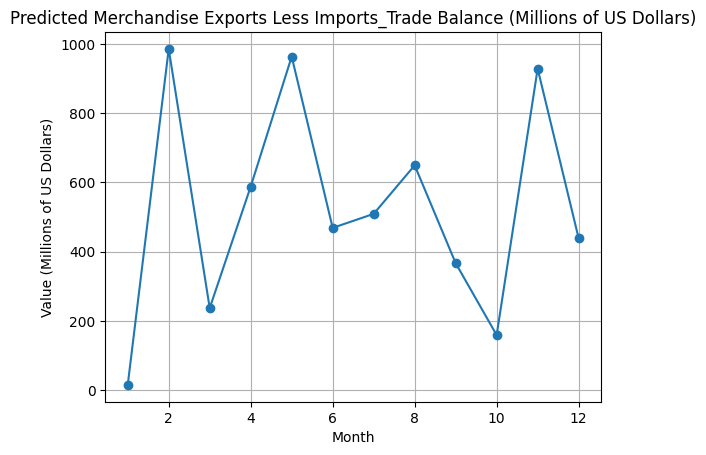

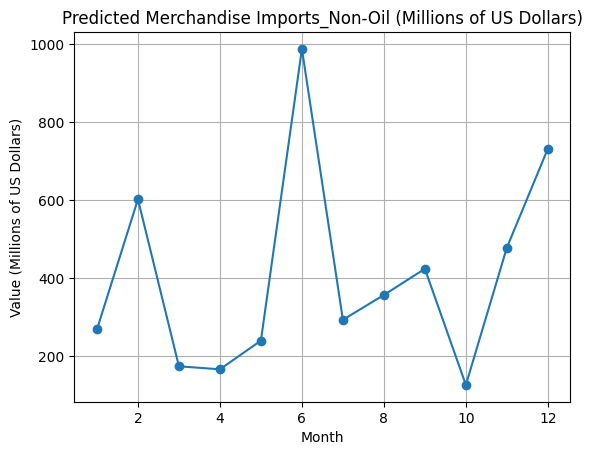

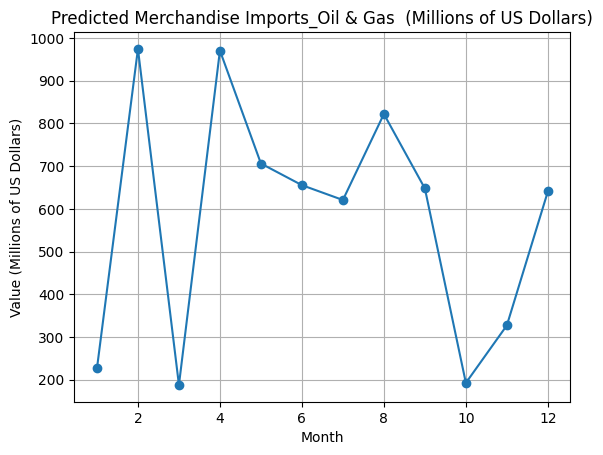

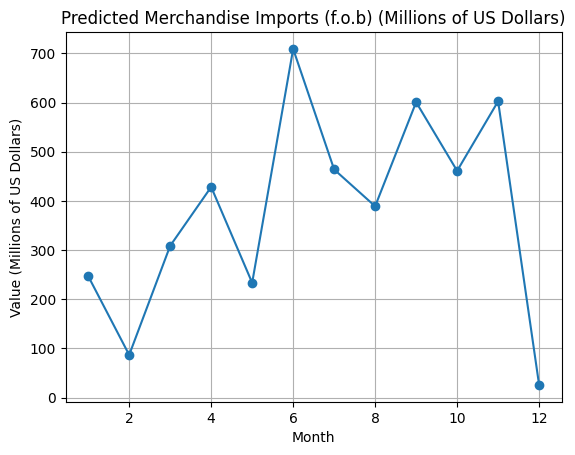

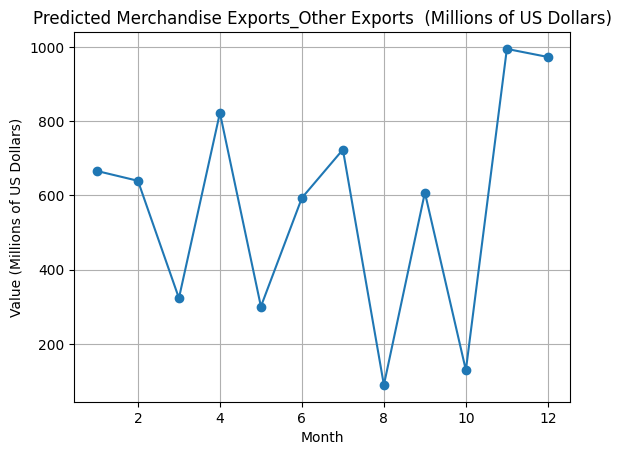

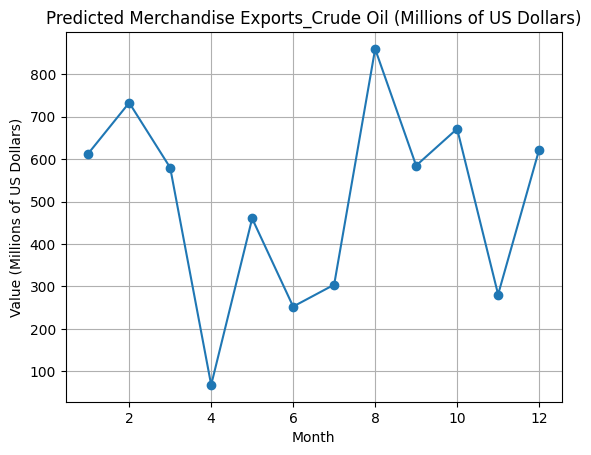

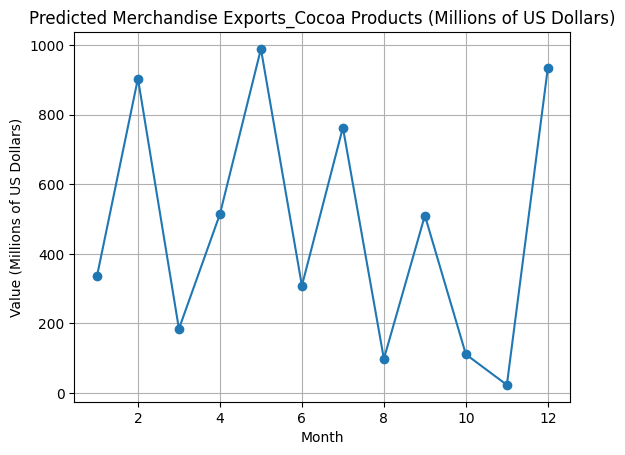

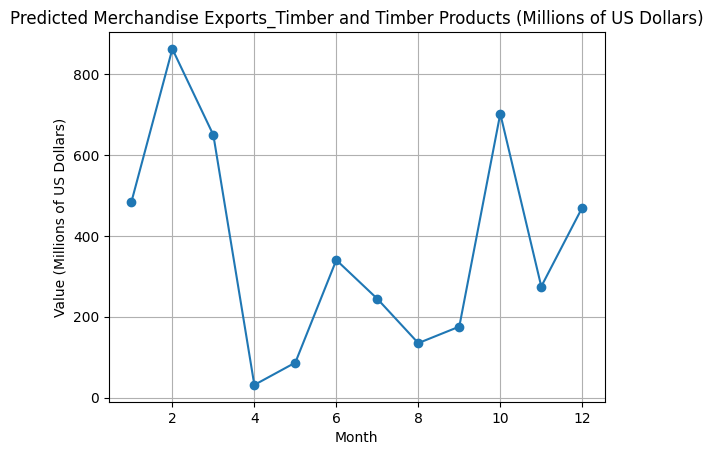

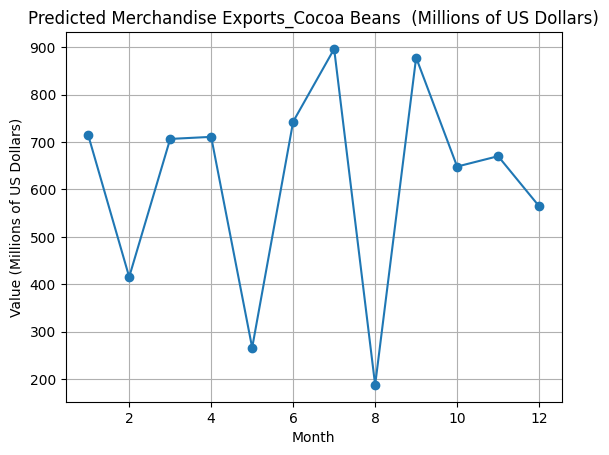

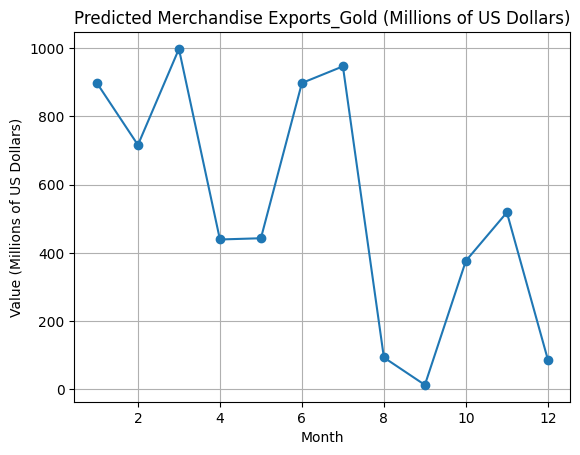

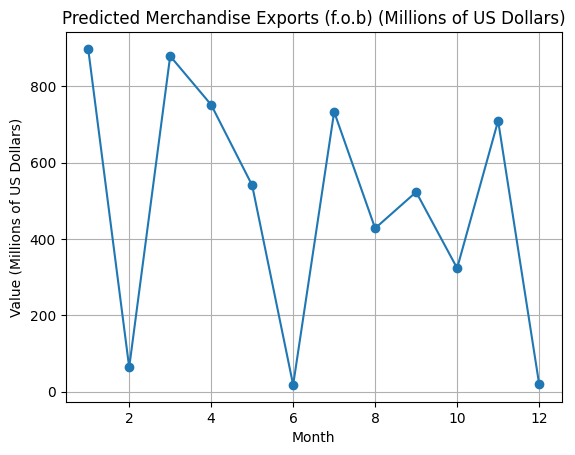

NotImplementedError: 
Layer QuantumLSTMTimeStepLayer has arguments ['n_qubits', 'weight_shapes']
in `__init__` and therefore must override `get_config()`.

Example:

class CustomLayer(keras.layers.Layer):
    def __init__(self, arg1, arg2):
        super().__init__()
        self.arg1 = arg1
        self.arg2 = arg2

    def get_config(self):
        config = super().get_config()
        config.update({
            "arg1": self.arg1,
            "arg2": self.arg2,
        })
        return config

In [31]:
"""Dynamic interpretation of economic predictions and suggestion of policies based on variable names and predicted values. It also visualizes the predictions for each variable across months."""

import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

num_variables_to_predict = 11  # Number of economic variables
num_months_to_predict = 12  # Number of months

# Assuming `original_predictions` is already computed
original_predictions = np.random.rand(1, num_months_to_predict, num_variables_to_predict) * 1000

# Placeholder variable names
variable_names = [
    'Merchandise Exports Less Imports_Trade Balance (Millions of US Dollars)',
    'Merchandise Imports_Non-Oil (Millions of US Dollars)',
    'Merchandise Imports_Oil & Gas  (Millions of US Dollars)',
    'Merchandise Imports (f.o.b) (Millions of US Dollars)',
    'Merchandise Exports_Other Exports  (Millions of US Dollars)',
    'Merchandise Exports_Crude Oil (Millions of US Dollars)',
    'Merchandise Exports_Cocoa Products (Millions of US Dollars)',
    'Merchandise Exports_Timber and Timber Products (Millions of US Dollars)',
    'Merchandise Exports_Cocoa Beans  (Millions of US Dollars)',
    'Merchandise Exports_Gold (Millions of US Dollars)',
    'Merchandise Exports (f.o.b) (Millions of US Dollars)'
]

# Define a function to dynamically interpret predictions
def interpret_predictions(variable, value):
    """
    Dynamically interprets economic predictions.
    """
    interpretation = f"The predicted value for {variable} is {value:.2f} (Millions of US Dollars). "
    if "Trade Balance" in variable:
        if value > 0:
            interpretation += "This indicates a trade surplus, which is positive for the economy."
        else:
            interpretation += "This indicates a trade deficit, which may signal economic challenges."
    elif "Imports" in variable:
        if value > 1000:
            interpretation += "High import levels could indicate dependency on foreign goods."
        else:
            interpretation += "Moderate import levels suggest balanced trade."
    elif "Exports" in variable:
        if value > 1000:
            interpretation += "Strong export performance supports foreign reserves."
        else:
            interpretation += "Weak exports could indicate competitiveness issues."
    else:
        interpretation += "No specific interpretation available."
    return interpretation

# Define a function to dynamically suggest policies
def suggest_policies(variable, value):
    """
    Dynamically generates policy recommendations based on predictions.
    """
    policy = "Policy Recommendations: "
    if "Trade Balance" in variable:
        if value < 0:
            policy += "Focus on reducing import dependency and promoting exports through diversification."
        else:
            policy += "Maintain surplus by supporting key export industries."
    elif "Imports" in variable:
        if value > 1000:
            policy += "Encourage domestic production and reduce non-essential imports."
        else:
            policy += "Ensure essential imports are sustained while managing reserves."
    elif "Exports" in variable:
        if value < 1000:
            policy += "Invest in improving production capacity and accessing new markets."
        else:
            policy += "Sustain export growth through targeted incentives and trade agreements."
    else:
        policy += "No specific policy recommendations available."
    return policy

# Analyze and interpret predictions dynamically
for month in range(num_months_to_predict):
    print(f"\nMonth: {month + 1}")
    for variable_index, variable_name in enumerate(variable_names):
        value = original_predictions[0][month][variable_index]
        interpretation = interpret_predictions(variable_name, value)
        policy = suggest_policies(variable_name, value)
        print(f"{variable_name}: {value:.2f} (Millions of US Dollars)")
        print(f"  Interpretation: {interpretation}")
        print(f"  Policy Recommendation: {policy}")

# Visualizing predictions
for variable_index, variable_name in enumerate(variable_names):
    plt.plot(range(1, num_months_to_predict + 1), original_predictions[0, :, variable_index], marker='o')
    plt.title(f"Predicted {variable_name}")
    plt.xlabel("Month")
    plt.ylabel("Value (Millions of US Dollars)")
    plt.grid()
    plt.show()

"""Converting a Keras Model to TFLite for Mobile Applications

To convert a machine learning model to TensorFlow Lite (TFLite), you can use TensorFlow's TFLiteConverter API. Here's a basic Python code example that demonstrates how to convert a TensorFlow/Keras model to TFLite format.
"""

# Save the Keras model in the specified format
model.save('qlstm_merchandize_trade_flows_model.keras')

# Load your Keras model with the custom metric specified
model = tf.keras.models.load_model('qlstm_merchandize_trade_flows_model.keras',
                                   custom_objects={'custom_loss': custom_loss, 'root_mean_squared_error': root_mean_squared_error})

# Convert the model to TensorFlow Lite format with proper settings
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable experimental resource variables
converter.experimental_enable_resource_variables = True

# Use TensorFlow Select ops (allows using TensorFlow ops in the TFLite model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,  # Use TFLite default ops
    tf.lite.OpsSet.SELECT_TF_OPS     # Enable TensorFlow operations for unsupported ops
]

# Disable lowering of TensorList ops
converter._experimental_lower_tensor_list_ops = False

# Convert the model
tflite_model = converter.convert()

# Save the converted model to a .tflite file
with open('qlstm_merchandize_trade_flows_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model converted and saved to 'qlstm_merchandize_trade_flows_model.tflite'")

In [33]:
class QuantumLSTMTimeStepLayer(tf.keras.layers.Layer):
    def __init__(self, n_qubits, weight_shapes):
        super(QuantumLSTMTimeStepLayer, self).__init__()
        self.n_qubits = n_qubits
        self.q_weights = self.add_weight(
            shape=weight_shapes['weights'],
            initializer='random_normal',
            dtype='float64',
            trainable=True,
            name='q_weights'
        )

    def call(self, inputs):
        # Quantum computation within the keras Layer
        output = quantum_lstm_cell(inputs, self.q_weights)
        return tf.shape(tf.cast(output, dtype=tf.float64), (1, self.n_qubits))

    # Override get_config to save layer configuration
    def get_config(self):
        config = super().get_config()
        config.update({
            "n_qubits": self.n_qubits,
            "weight_shapes": {"weights": (2, self.n_qubits, 3)}  # You might need to adjust the shape based on your actual weight_shapes
        })
        return config